# __Cloning Repository from GitHub__

In [ ]:
! git clone https://github.com/juanmafdez/LLP_APP_Colombia

Cloning into 'LLP_APP_Colombia'...
remote: Enumerating objects: 274, done.
remote: Counting objects: 100% (274/274), done.
remote: Compressing objects: 100% (235/235), done.
remote: Total 274 (delta 104), reused 117 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (274/274), 2.25 MiB | 8.09 MiB/s, done.
Resolving deltas: 100% (104/104), done.


# __Installing and Importing Libraries__

In [ ]:
import os, sys, time, random, math, shutil, glob
from tensorflow.keras import mixed_precision
from itertools import accumulate
from itertools import groupby
from pathlib import Path
import tensorflow as tf
from PIL import Image
import numpy as np
import tifffile

In [ ]:
sys.path.append('LLP_APP_Colombia/swav')
import architecture
import multicrop_dataset

# __Storage Management__

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# __Data Structuring__

In [ ]:
data_path = '/content/drive/MyDrive/llp_col_project/datasets/sentinel'
final_output = "/content/train_data"
os.makedirs(final_output, exist_ok=True)
departments = {
    'boyaca': 'boy_partitions_aschips_32bc4829188e3',
    'magdalena': 'mag_partitions_aschips_114531b2fa759',
    'caldas': 'cal_partitions_aschips_1f8c74cc7e29b'
}
for alias, folder_name in departments.items():
    print(f"--- Unzipping {alias} ---")
    !unzip -o -q {data_path}/{folder_name}.zip -d /content/
    full_path = f"/content/*/{folder_name}/sentinel2-rgb-median-2020"
    found_dirs = glob.glob(full_path)
    if found_dirs:
        src_dir = found_dirs[0]
        files = os.listdir(src_dir)
        print(f"Found files: {len(files)}")
        for f in files:
            src_file = os.path.join(src_dir, f)
            dst_file = os.path.join(final_output, f"{alias}_{f}")
            shutil.move(src_file, dst_file)
        print(f"{alias} moved correctly.")
    else:
        print(f"{alias} not found")
    !rm -rf /content/gjson_data*
print(f"\n--- Process Finished ---")
print(f"Total files in {final_output}: {len(os.listdir(final_output))}")

--- Unzipping boyaca ---
Found files: 24194
boyaca moved correctly.
--- Unzipping magdalena ---
Found files: 23400
magdalena moved correctly.
--- Unzipping caldas ---
Found files: 7901
caldas moved correctly.

--- Process Finished ---
Total files in /content/train_data: 55495


# __Pretraining with SwAV__

## __Global Parameters Definition__

In [ ]:
SEED = 666
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
try:
    tf.config.experimental.enable_op_determinism(True)
except Exception:
    pass

mixed_precision.set_global_policy('mixed_float16')

In [ ]:
DATA_DIR = '/content/train_data'

In [ ]:
SIZE_CROPS = [90,50]
NUM_CROPS = [2,3]
MIN_SCALE = [0.8,0.3]
MAX_SCALE = [1.0,0.8]

In [ ]:
NUM_PROTOTYPES = 100
TAU_SINKHORN = 0.1
TAU_SOFTMAX_P = 0.3
SINKHORN_ITERS = 3

In [ ]:
BETA_P_ENTROPY  = tf.constant(0.05, dtype=tf.float32)
LAMBDA_PROTO_L2 = tf.constant(1e-6, dtype=tf.float32)

In [ ]:
EPOCHS_CONTINUE = 15
BATCH_SIZE = 128
ACCUM_STEPS = 1
INIT_LR = 1e-2
WEIGHT_DECAY = 1e-4
CLIP_NORM = 1

In [ ]:
CKPT_DIR = '/content/drive/MyDrive/llp_col_project/swav_checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)
BACKBONE_LATEST = os.path.join(CKPT_DIR, 'feature_backbone_latest.weights.h5')
PROJPROTO_LATEST = os.path.join(CKPT_DIR, 'projection_prototype_latest.weights.h5')
EPOCH_TRACK = os.path.join(CKPT_DIR, 'swav_epoch.txt')

In [ ]:
AUTO = tf.data.AUTOTUNE

## __Images Management__

In [ ]:
def list_tif_files(root):
    files = tf.io.gfile.glob(os.path.join(root, '*.tif'))
    files = [f for f in files if tf.io.gfile.exists(f)]
    return files

In [ ]:
all_files = sorted(list_tif_files(DATA_DIR))
print(f'Total .tif files: {len(all_files)}')

Total .tif files: 55495


In [ ]:
split_idx = int(0.8 * len(all_files))
train_files = all_files[:split_idx]
val_files = all_files[split_idx:]

In [ ]:
SRC_DIR = '/content/train_data'
PNG_DIR = '/content/train_data_png8'
os.makedirs(PNG_DIR, exist_ok=True)
def save_png8_from_array(img_np: np.ndarray, out_path: str):
    if img_np.ndim == 3 and img_np.shape[0] < img_np.shape[1]:
        img_np = np.transpose(img_np, (1, 2, 0))
    elif img_np.ndim == 2:
        img_np = img_np[..., None]
    if img_np.shape[-1] == 1:
        img_np = np.repeat(img_np, 3, axis=-1)
    elif img_np.shape[-1] > 3:
        img_np = img_np[..., :3]
    arr = img_np.astype(np.uint8)
    im = Image.fromarray(arr)
    im.save(out_path, format='PNG', compress_level=0)
tif_paths = sorted(glob.glob(os.path.join(SRC_DIR, '*.tif')))
print(f"Converting {len(tif_paths)} TIFF a PNG 8-bit (lossless)...")
converted = 0
for p in tif_paths:
    out_path = os.path.join(PNG_DIR, Path(p).stem + '.png')
    if not os.path.exists(out_path):
        arr = tifffile.imread(p)
        save_png8_from_array(arr, out_path)
        converted += 1
total_png = len(glob.glob(os.path.join(PNG_DIR, '*.png')))
print(f"Done. Converted: {converted}. Total PNG created: {total_png}")

Converting 55495 TIFF a PNG 8-bit (lossless)...
Done. Converted: 55495. Total PNG created: 55495


In [ ]:
def load_png_uint8(path):
    im = Image.open(path)
    arr = np.array(im)
    if arr.ndim == 2:
        arr = np.stack([arr]*3, axis=-1)
    elif arr.shape[-1] > 3:
        arr = arr[..., :3]
    return arr
samples = random.sample(tif_paths, min(10, len(tif_paths)))
mismatches = 0
for p in samples:
    t = tifffile.imread(p)
    if t.ndim == 3 and t.shape[0] < t.shape[1]:
        t = np.transpose(t, (1,2,0))
    if t.ndim == 2:
        t = np.stack([t]*3, axis=-1)
    elif t.shape[-1] > 3:
        t = t[..., :3]
    t = t.astype(np.uint8)
    png_path = os.path.join(PNG_DIR, Path(p).stem + '.png')
    p_arr = load_png_uint8(png_path)
    if not np.array_equal(t, p_arr):
        mismatches += 1
        print(f"Detected difference in: {p}")

if mismatches == 0:
    print("Verification: TIFF uint8 and PNG 8-bit are equivalents.")
else:
    print(f"Verification: {mismatches} differences in {len(samples)} samples.")

Verification: TIFF uint8 and PNG 8-bit are equivalents.


In [ ]:
def list_png_files(root):
    files = tf.io.gfile.glob(os.path.join(root, '*.png'))
    return sorted(files)
all_png = list_png_files(PNG_DIR)
print(f"PNG found: {len(all_png)}")

split_idx = int(0.8 * len(all_png))
train_files = all_png[:split_idx]
val_files   = all_png[split_idx:]

def decode_png(path):
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_png(img_bytes, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img.set_shape([None, None, 3])
    return img

PNG found: 55495


In [ ]:
def build_dataset(file_list, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices(file_list)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(file_list), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(decode_png, num_parallel_calls=AUTO)
    return ds

In [ ]:
train_img_ds = build_dataset(train_files, shuffle=True)
val_img_ds = build_dataset(val_files, shuffle=False)

In [ ]:
trainloaders = multicrop_dataset.get_multires_dataset(
    train_img_ds,
    size_crops=SIZE_CROPS,
    num_crops=NUM_CROPS,
    min_scale=MIN_SCALE,
    max_scale=MAX_SCALE,
    options=None
)

In [ ]:
trainloaders_zipped = tf.data.Dataset.zip(trainloaders)
trainloaders_zipped = (
    trainloaders_zipped
      .shuffle(buffer_size=1024, seed=SEED, reshuffle_each_iteration=True)
      .batch(BATCH_SIZE)
      .prefetch(AUTO)
)

In [ ]:
im1, im2, im3, im4, im5 = next(iter(trainloaders_zipped))
print('View shapes:', im1.shape, im2.shape, im3.shape, im4.shape, im5.shape)

View shapes: (128, 90, 90, 3) (128, 90, 90, 3) (128, 50, 50, 3) (128, 50, 50, 3) (128, 50, 50, 3)


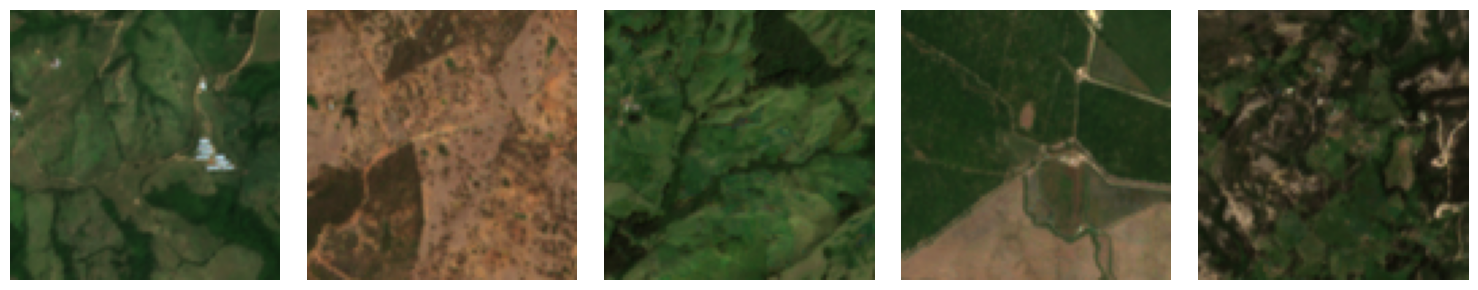

In [ ]:
import matplotlib.pyplot as plt
imgs_test_view = random.sample(list(Path("/content/train_data_png8").glob("*.png")), 5)
plt.figure(figsize=(15,3))
for i, img_path in enumerate(imgs_test_view, 1):
    plt.subplot(1,5,i)
    plt.imshow(Image.open(img_path))
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
feature_backbone = architecture.get_resnet_backbone()
projection_prototype = architecture.get_projection_prototype(2048, 256, NUM_PROTOTYPES)

In [ ]:
@tf.function
def sinkhorn_logits(logits, tau=0.05, num_iters=3, eps=1e-8):
    logits = tf.cast(logits, tf.float32)
    Q = tf.transpose(tf.exp(logits / tau))
    Q = Q / (tf.reduce_sum(Q) + eps)
    K = tf.shape(Q)[0]
    B = tf.shape(Q)[1]
    r = tf.ones([K], dtype=tf.float32) / tf.cast(K, tf.float32)
    c = tf.ones([B], dtype=tf.float32) / tf.cast(B, tf.float32)
    for _ in range(num_iters):
        Q *= tf.expand_dims(r / (tf.reduce_sum(Q, axis=1) + eps), axis=1)
        Q *= tf.expand_dims(c / (tf.reduce_sum(Q, axis=0) + eps), axis=0)
    Q = Q / (tf.reduce_sum(Q, axis=0, keepdims=True) + eps)
    return tf.transpose(Q)

In [ ]:
num_train_images = len(train_files)
steps_per_epoch  = math.ceil(num_train_images / BATCH_SIZE)
optimizer_steps_per_epoch = steps_per_epoch
epochs_for_decay = 40
decay_steps = optimizer_steps_per_epoch * epochs_for_decay
WARMUP_STEPS = 300
class WarmupThenCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, warmup_steps, decay_steps):
        self.base_lr = base_lr
        self.warmup_steps = tf.cast(warmup_steps, tf.float32)
        self.cosine = tf.keras.optimizers.schedules.CosineDecay(base_lr, decay_steps)
    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warm = self.base_lr * (step / tf.maximum(1.0, self.warmup_steps))
        return tf.where(step < self.warmup_steps, warm, self.cosine(step - self.warmup_steps))
if WARMUP_STEPS > 0:
    lr_schedule = WarmupThenCosine(INIT_LR, WARMUP_STEPS, decay_steps)
else:
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(INIT_LR, decay_steps)
try:
    optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9, nesterov=True)
except Exception:
    optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9)

In [ ]:
train_vars = feature_backbone.trainable_variables + projection_prototype.trainable_variables
accum_grads_vars = [tf.Variable(tf.zeros_like(v), trainable=False, dtype=v.dtype) for v in train_vars]
accum_step = tf.Variable(0, dtype=tf.int32, trainable=False)

In [ ]:
IDX_CROPS_PY = list(accumulate(NUM_CROPS))
ASSIGN_CROPS = list(range(NUM_CROPS[0]))
TOTAL_VIEWS = sum(NUM_CROPS)
@tf.function
def train_step(input_views):
    im1, im2, im3, im4, im5 = input_views
    inputs = [im1, im2, im3, im4, im5]
    batch_size = tf.shape(inputs[0])[0]
    with tf.GradientTape() as tape:
        start_idx = 0
        embeddings_list = []
        for end_idx in IDX_CROPS_PY:  # [2,5]
            concat_input = tf.concat(inputs[start_idx:end_idx], axis=0)
            emb = feature_backbone(concat_input, training=True)
            embeddings_list.append(emb)
            start_idx = end_idx
        embeddings = tf.concat(embeddings_list, axis=0)
        projection, prototype_logits = projection_prototype(embeddings, training=True)
        loss_dtype = prototype_logits.dtype
        loss = tf.zeros([], dtype=loss_dtype)
        K = tf.shape(prototype_logits)[-1]
        p_hist_sum = tf.zeros([K], dtype=tf.float32)
        total_p_count = tf.constant(0.0, dtype=tf.float32)
        for crop_id in ASSIGN_CROPS:
            out = prototype_logits[batch_size * crop_id: batch_size * (crop_id + 1)]
            q = sinkhorn_logits(out, tau=TAU_SINKHORN, num_iters=SINKHORN_ITERS)
            q = tf.stop_gradient(q)
            subloss = tf.zeros([], dtype=loss_dtype)
            for v in range(TOTAL_VIEWS):
                if v == crop_id:
                    continue
                logits_v = prototype_logits[batch_size * v: batch_size * (v + 1)]
                logits_v_centered = logits_v - tf.reduce_mean(logits_v, axis=1, keepdims=True)
                p_f32 = tf.nn.softmax(tf.cast(logits_v_centered, tf.float32) / TAU_SOFTMAX_P)
                ce_f32 = -tf.reduce_mean(tf.reduce_sum(q * tf.math.log(p_f32 + 1e-8), axis=1))
                H_p_f32 = -tf.reduce_mean(tf.reduce_sum(p_f32 * tf.math.log(p_f32 + 1e-8), axis=1))
                p_hist_sum += tf.reduce_sum(p_f32, axis=0)
                total_p_count += tf.cast(tf.shape(p_f32)[0], tf.float32)
                ce   = tf.cast(ce_f32, loss_dtype)
                H_p  = tf.cast(H_p_f32, loss_dtype)
                beta = tf.cast(BETA_P_ENTROPY, loss_dtype)
                subloss += ce - beta * H_p
            subloss /= tf.cast((TOTAL_VIEWS - 1), loss_dtype)
            loss += subloss
        loss /= tf.cast(len(ASSIGN_CROPS), loss_dtype)
        hist_p = p_hist_sum / (total_p_count + 1e-8)
        log_u = -tf.math.log(tf.cast(NUM_PROTOTYPES, tf.float32))
        kl_hist_u = tf.reduce_sum(hist_p * (tf.math.log(hist_p + 1e-8) - log_u))
        GAMMA_P_BAL = tf.constant(0.05, dtype=tf.float32)
        loss += tf.cast(GAMMA_P_BAL * kl_hist_u, loss_dtype)
        proto_kernel = projection_prototype.get_layer('prototype').kernel
        reg_f32 = tf.nn.l2_loss(tf.cast(proto_kernel, tf.float32))
        loss += tf.cast(LAMBDA_PROTO_L2, loss_dtype) * tf.cast(reg_f32, loss_dtype)
        W = projection_prototype.get_layer('prototype').kernel
        Wf32 = tf.cast(W, tf.float32)
        W_norm = Wf32 / (tf.norm(Wf32, axis=0, keepdims=True) + 1e-8)
        G = tf.matmul(tf.transpose(W_norm), W_norm)
        off_diag = G - tf.eye(tf.shape(G)[0], dtype=G.dtype)
        PROTO_DECORR_LAMBDA = tf.constant(1e-3, dtype=tf.float32)
        decor_loss = PROTO_DECORR_LAMBDA * tf.reduce_sum(tf.square(off_diag))
        loss += tf.cast(decor_loss, loss_dtype)
    grads = tape.gradient(loss, train_vars)
    grads = [tf.zeros_like(v) if g is None else g for g, v in zip(grads, train_vars)]
    grads = [tf.cast(g, v.dtype) for g, v in zip(grads, train_vars)]
    grads, _ = tf.clip_by_global_norm(grads, CLIP_NORM)
    for ag, g in zip(accum_grads_vars, grads):
        ag.assign_add(g)
    accum_step.assign_add(1)
    apply_now = tf.equal(tf.math.floormod(accum_step, ACCUM_STEPS), 0)
    def _apply_and_reset():
        mean_grads = [ag / tf.cast(ACCUM_STEPS, ag.dtype) for ag in accum_grads_vars]
        optimizer.apply_gradients(zip(mean_grads, train_vars))
        for ag in accum_grads_vars:
            ag.assign(tf.zeros_like(ag))
        return tf.constant(True)
    applied = tf.cond(apply_now, _apply_and_reset, lambda: tf.constant(False))
    return loss, applied

In [ ]:
@tf.function
def proto_usage_counts_centered(prototype_logits, batch_size, total_views, num_prototypes, tau=0.30):
    counts = tf.zeros([num_prototypes], dtype=tf.int32)
    for v in tf.range(total_views):
        logits_v = prototype_logits[batch_size * v : batch_size * (v + 1)]
        logits_v_centered = logits_v - tf.reduce_mean(logits_v, axis=1, keepdims=True)
        p = tf.nn.softmax(tf.cast(logits_v_centered, tf.float32) / tau)
        idx = tf.argmax(p, axis=1, output_type=tf.int32)
        counts += tf.math.bincount(idx, minlength=num_prototypes, maxlength=num_prototypes)
    return counts

@tf.function
def q_entropy_from_logits(out_logits, tau_sink=0.07, iters=2):
    q = sinkhorn_logits(out_logits, tau=tau_sink, num_iters=iters)
    ent = -tf.reduce_sum(q * tf.math.log(q + 1e-8), axis=1)
    return tf.reduce_mean(ent)

def forward_once(input_views, feature_backbone, projection_prototype, idx_crops_py):
    im1, im2, im3, im4, im5 = input_views
    inputs = [im1, im2, im3, im4, im5]
    start_idx = 0
    embeddings_list = []
    for end_idx in idx_crops_py:
        concat_input = tf.concat(inputs[start_idx:end_idx], axis=0)
        _emb = feature_backbone(concat_input, training=False)
        embeddings_list.append(_emb)
        start_idx = end_idx
    embeddings = tf.concat(embeddings_list, axis=0)
    projection, prototype_logits = projection_prototype(embeddings, training=False)
    return projection, prototype_logits

In [ ]:
def l2_normalize_prototypes(model_projproto):
    try:
        w = model_projproto.get_layer('prototype').get_weights()
        W = tf.convert_to_tensor(w[0])
        W_t = tf.transpose(W)
        W_t = tf.math.l2_normalize(W_t, axis=1)
        W_new = tf.transpose(W_t)
        model_projproto.get_layer('prototype').set_weights([W_new])
    except Exception as e:
        print('Prototype L2 normalize skipped:', e)

In [ ]:
ckpt = tf.train.Checkpoint(
    optimizer=optimizer,
    backbone=feature_backbone,
    projproto=projection_prototype,
    accum_step=accum_step
)
ckpt_mgr = tf.train.CheckpointManager(ckpt, CKPT_DIR, max_to_keep=1)

In [ ]:
def try_restore_or_load_h5():
    start_epoch = 0
    restored_from = "none"
    latest = ckpt_mgr.latest_checkpoint
    if latest:
        ckpt.restore(latest).expect_partial()
        restored_from = f"TF checkpoint: {latest}"
        if tf.io.gfile.exists(EPOCH_TRACK):
            with tf.io.gfile.GFile(EPOCH_TRACK, 'r') as f:
                try:
                    start_epoch = int(f.read().strip())
                except:
                    start_epoch = 0
        print(f"Restored from {restored_from} | start_epoch={start_epoch}")
        return start_epoch, restored_from
    if tf.io.gfile.exists(BACKBONE_LATEST):
        feature_backbone.load_weights(BACKBONE_LATEST)
        restored_from = f"H5 backbone: {BACKBONE_LATEST}"
        print(f"Backbone loaded from {BACKBONE_LATEST}")
    if tf.io.gfile.exists(PROJPROTO_LATEST):
        projection_prototype.load_weights(PROJPROTO_LATEST)
        restored_from += f" + H5 projproto: {PROJPROTO_LATEST}"
        print(f"Projection-Prototype loaded from {PROJPROTO_LATEST}")
    if tf.io.gfile.exists(EPOCH_TRACK):
        with tf.io.gfile.GFile(EPOCH_TRACK, 'r') as f:
            try:
                start_epoch = int(f.read().strip())
            except:
                start_epoch = 0
    if restored_from == "none":
        print("Couldn't find checkpoint for TF or H5; Train will be from scratch.")
    else:
        print(f"Restored from: {restored_from} | start_epoch={start_epoch}")
    return start_epoch, restored_from
start_epoch, restored_from = try_restore_or_load_h5()

Restored from TF checkpoint: /content/drive/MyDrive/llp_col_project/swav_checkpoints/ckpt-61 | start_epoch=61


In [ ]:
fb = feature_backbone
NEW_NUM_PROTOTYPES = 50
projection_prototype = architecture.get_projection_prototype(2048, 256, NEW_NUM_PROTOTYPES)
train_vars = fb.trainable_variables + projection_prototype.trainable_variables
accum_grads_vars = [tf.Variable(tf.zeros_like(v), trainable=False, dtype=v.dtype) for v in train_vars]
accum_step = tf.Variable(0, dtype=tf.int32, trainable=False)
NUM_PROTOTYPES = NEW_NUM_PROTOTYPES

In [ ]:
def train_swav(
    feature_backbone,
    projection_prototype,
    dataloader,
    optimizer,
    ckpt_mgr,
    epochs_to_run,
    start_epoch=0,
    freeze_proto_epochs=3,
    verbose=True
):
    import time
    import numpy as np
    import tensorflow as tf
    import os
    t0 = time.time()
    history = []
    current_epoch = start_epoch
    for epoch in range(start_epoch + 1, start_epoch + 1 + epochs_to_run):
        current_epoch = epoch
        if freeze_proto_epochs > 0 and epoch <= (start_epoch + freeze_proto_epochs):
            projection_prototype.get_layer('prototype').trainable = False
            if verbose:
                print(f"[Epoch {epoch:03d}] Prototype layer: FROZEN (anti‑collapse warmup)")
        else:
            projection_prototype.get_layer('prototype').trainable = True
            if verbose:
                print(f"[Epoch {epoch:03d}] Prototype layer: trainable")
        l2_normalize_prototypes(projection_prototype)
        step_losses = []
        applied_steps = 0
        first_batch = True
        for batch_views in dataloader:
            loss, applied = train_step(batch_views)
            step_losses.append(float(loss.numpy()))
            if bool(applied.numpy()):
                applied_steps += 1
                l2_normalize_prototypes(projection_prototype)
            if first_batch and verbose:
                proj_dbg, proto_logits_dbg = forward_once(
                    batch_views,
                    feature_backbone,
                    projection_prototype,
                    IDX_CROPS_PY
                )
                bsz = tf.shape(batch_views[0])[0]
                logits0 = proto_logits_dbg[0:bsz]
                logits0_centered = logits0 - tf.reduce_mean(logits0, axis=1, keepdims=True)
                p0 = tf.nn.softmax(tf.cast(logits0_centered, tf.float32) / TAU_SOFTMAX_P)
                H_p = float(tf.reduce_mean(-tf.reduce_sum(p0 * tf.math.log(p0 + 1e-8), axis=1)).numpy())
                counts = proto_usage_counts_centered(
                    proto_logits_dbg, bsz, TOTAL_VIEWS, NUM_PROTOTYPES, tau=TAU_SOFTMAX_P
                )
                counts_np = counts.numpy()
                k_min, k_max = counts_np.min(), counts_np.max()
                top5_idx = counts_np.argsort()[-5:][::-1]
                top5_pairs = list(zip(top5_idx.tolist(), counts_np[top5_idx].tolist()))
                out0 = proto_logits_dbg[0:bsz]
                ent_q = float(q_entropy_from_logits(
                    out0, tau_sink=TAU_SINKHORN, iters=SINKHORN_ITERS
                ).numpy())
                print(f"[Diag] proto-usage: min={k_min}, max={k_max}, top5={top5_pairs}")
                print(f"[Diag] q-entropy(view0): {ent_q:.4f}")
                print(f"[Diag] p-entropy(view0): {H_p:.4f}")
                first_batch = False
        epoch_loss = float(np.mean(step_losses)) if len(step_losses) > 0 else float('nan')
        history.append(epoch_loss)
        print(f"[Epoch {epoch:03d}] loss={epoch_loss:.4f} | optimizer steps={applied_steps}")
        ckpt_mgr.save(checkpoint_number=epoch)
        tmp_fb = '/content/feature_backbone_tmp.weights.h5'
        feature_backbone.save_weights(tmp_fb)
        tf.io.gfile.copy(tmp_fb, BACKBONE_LATEST, overwrite=True)
        try:
            os.remove(tmp_fb)
        except Exception:
            pass
        tmp_pp = '/content/projection_prototype_tmp.weights.h5'
        projection_prototype.save_weights(tmp_pp)
        tf.io.gfile.copy(tmp_pp, PROJPROTO_LATEST, overwrite=True)
        try:
            os.remove(tmp_pp)
        except Exception:
            pass
        with tf.io.gfile.GFile(EPOCH_TRACK, 'w') as f:
            f.write(str(epoch))
    print(f"Total time: {(time.time() - t0)/60:.2f} min")
    return history

In [ ]:
history = train_swav(
    feature_backbone,
    projection_prototype,
    trainloaders_zipped,
    epochs_to_run=EPOCHS_CONTINUE,
    start_epoch=start_epoch,
    ckpt_mgr=ckpt_mgr,
    optimizer=optimizer
)

[Epoch 062] Prototype layer: FROZEN (anti‑collapse warmup)
[Diag] proto-usage: min=0, max=355, top5=[(40, 355), (49, 251), (17, 14), (22, 10), (0, 9)]
[Diag] q-entropy(view0): 3.8988
[Diag] p-entropy(view0): 3.8942
[Epoch 062] loss=3.7427 | optimizer steps=347
[Epoch 063] Prototype layer: FROZEN (anti‑collapse warmup)
[Diag] proto-usage: min=0, max=352, top5=[(45, 352), (39, 223), (40, 31), (13, 13), (46, 9)]
[Diag] q-entropy(view0): 3.8680
[Diag] p-entropy(view0): 3.8926
[Epoch 063] loss=3.7429 | optimizer steps=347
[Epoch 064] Prototype layer: FROZEN (anti‑collapse warmup)
[Diag] proto-usage: min=0, max=359, top5=[(45, 359), (4, 223), (40, 33), (13, 11), (8, 4)]
[Diag] q-entropy(view0): 3.8771
[Diag] p-entropy(view0): 3.8930
[Epoch 064] loss=3.7429 | optimizer steps=347
[Epoch 065] Prototype layer: trainable
[Diag] proto-usage: min=0, max=349, top5=[(45, 349), (4, 221), (40, 41), (13, 14), (46, 5)]
[Diag] q-entropy(view0): 3.8754
[Diag] p-entropy(view0): 3.8930
[Epoch 065] loss=3.742